In [1]:
!pip3 install pandas keras tensorflow scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
# Load the dataset CSV file
# Format: 
#   filename - original stl file name, for tracking
#   d - distance to object in mm
#   o - distance between cameras in mm
#   rx, ry, rz - rotation angles in degrees
#   left - path to left image
#  right - path to right image
dataset_file = './stl_data/base_permuted_output/256x256/base_permuted.csv'

# Set the image size for loading images & building the neural network model
image_size = (256, 256)

X (merged L+R stereo images) shape: (134, 256, 256, 2)
y (distance d) shape: (134,)


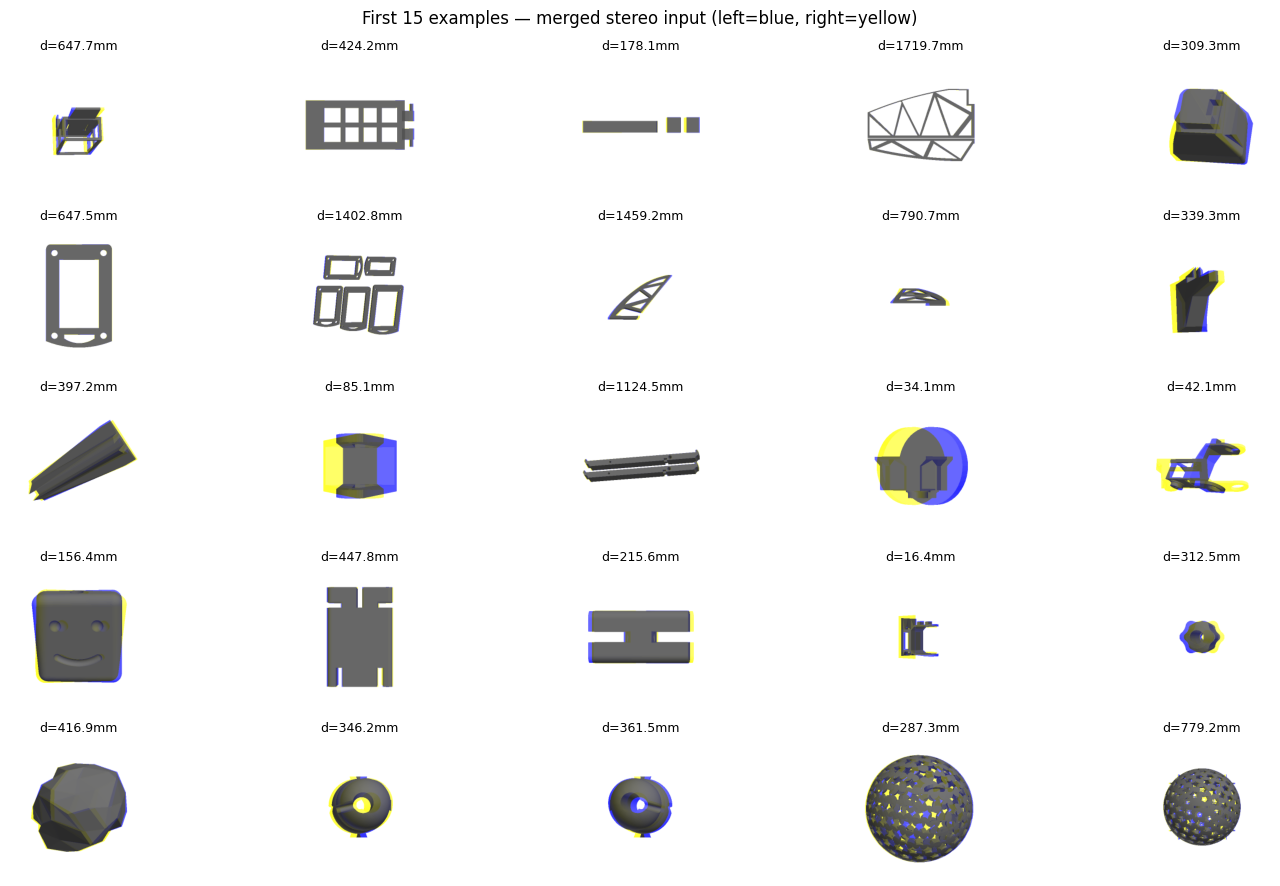

In [6]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
df = pd.read_csv(dataset_file)
dataset_path = os.path.dirname(dataset_file)

# The source renders are single-channel grayscale (mode "L"), not RGB.
# Merge each stereo pair into one 2-channel image: channel 0 = left, channel 1 = right.
# This is early fusion (approach B): the network sees L and R as two dimensions of
# ONE input, the same way an RGB image's 3 channels are treated as one input.
left_imgs, right_imgs, d_values = [], [], []
missing_files = []

for _, row in df.iterrows():
    left_path = os.path.join(dataset_path, row["left"])
    right_path = os.path.join(dataset_path, row["right"])

    if not os.path.exists(left_path) or not os.path.exists(right_path):
        missing_files.append((left_path, right_path))
        continue

    left_imgs.append(np.asarray(Image.open(left_path).convert("L")))
    right_imgs.append(np.asarray(Image.open(right_path).convert("L")))
    d_values.append(row["d"])

if missing_files:
    print(f"{len(missing_files)} missing image files for some rows:", missing_files)
    raise FileNotFoundError("Dataset is corrupt; Some image files are missing. Please check the paths.")

X = np.stack([np.stack([l, r], axis=-1) for l, r in zip(left_imgs, right_imgs)])
y = np.array(d_values, dtype="float32")

print(f"X (merged L+R stereo images) shape: {X.shape}")
print(f"y (distance d) shape: {y.shape}")

# Visualize the first 25 examples. The 2-channel data isn't directly viewable as an
# image, so for display only: left channel -> blue, right channel -> yellow.
n_show = 25
fig, axes = plt.subplots(5, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat[:n_show]):
    left_norm = X[i, :, :, 0].astype("float32") / 255.0
    right_norm = X[i, :, :, 1].astype("float32") / 255.0
    vis = np.stack([right_norm, right_norm, left_norm], axis=-1)  # yellow = R+G, blue = B
    ax.imshow(vis)
    ax.set_title(f"d={y[i]:.1f}mm", fontsize=9)
    ax.axis("off")
plt.suptitle("First 15 examples — merged stereo input (left=blue, right=yellow)")
plt.tight_layout()
plt.show()

In [13]:
# Build the neural network model, and output the model summary

import tensorflow as tf

input_shape = image_size + (2,)

def model_tree(input_tensor):
    x = tf.keras.layers.Conv2D(32, 5, activation="relu", padding="same")(input_tensor)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Flatten()(x) 
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(1, activation="linear", name = "d")(x)
    return x

input_image = tf.keras.Input(shape=input_shape, name="image_stereo")
output_d = model_tree(input_image)

model = tf.keras.Model(inputs=input_image, outputs=output_d)
model.compile(optimizer="adam", loss="mse", )

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_stereo (InputLayer)       │ (None, 256, 256, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 32)   │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d (Dense)                       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,395,121 (32.02 MB)

 Trainable params: 8,395,121 (32.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# normalize image data for training
adjusted_images = X.astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    adjusted_images, y, test_size=0.2, random_state=42, shuffle=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=20,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 544943.1875 - val_loss: 147042.6250
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 232681.2656 - val_loss: 175549.7969
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 241526.1562 - val_loss: 95254.5156
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 210484.2344 - val_loss: 95420.4219
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 201970.1719 - val_loss: 134330.0469
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 221320.8125 - val_loss: 102221.1797
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 239972.6719 - val_loss: 90217.5234
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 188463.7812 - val_loss: 90918.9531
Epoch 9/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 188163.4375 - val_loss: 100455.8516
Epoch 10/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 172236.6719 - val_loss: 93771.4453
Epoch 11/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 25557

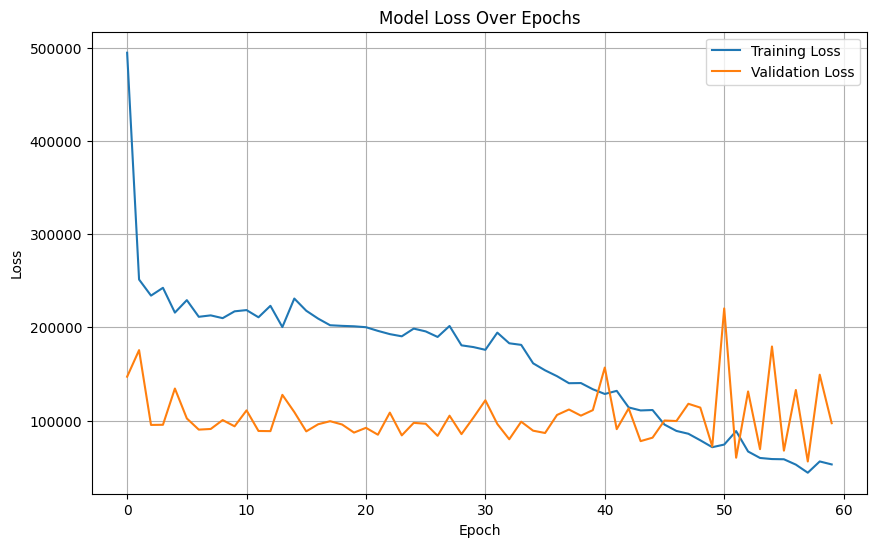

In [15]:
# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


/Users/nivnoach/Library/Python/3.9/lib/python/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image_stereo
Received: inputs=('Tensor(shape=(27, 256, 256, 2))',)
  warnings.warn(msg)


Test accuracy: 0.0000
Test weighted F1 score: 0.0000
Confusion matrix:


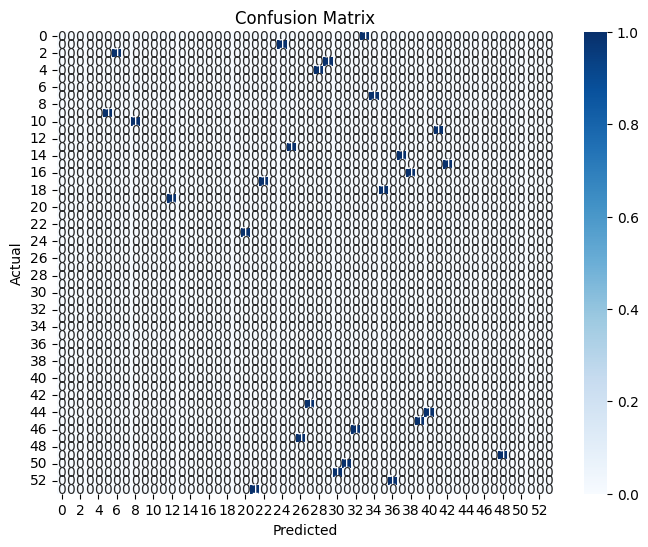

In [16]:
# Evaluate the model on the test set and print accuracy, F1 score, and confusion matrix
# 
# Confusion matrix and F1 score are more meaningful for classification tasks, but since
# this is a regression task, we will convert the continuous outputs to discrete labels
# for evaluation purposes.

import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict([X_test]).flatten()

# convert regression outputs to discrete labels for accuracy / f1 / confusion matrix
y_test_cls = np.rint(y_test).astype(int)
y_pred_cls = np.rint(y_pred).astype(int)

acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
cm = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Test accuracy: {acc:.4f}")
print(f"Test weighted F1 score: {f1:.4f}")
print("Confusion matrix:")

# Display the confusion matrix as a heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

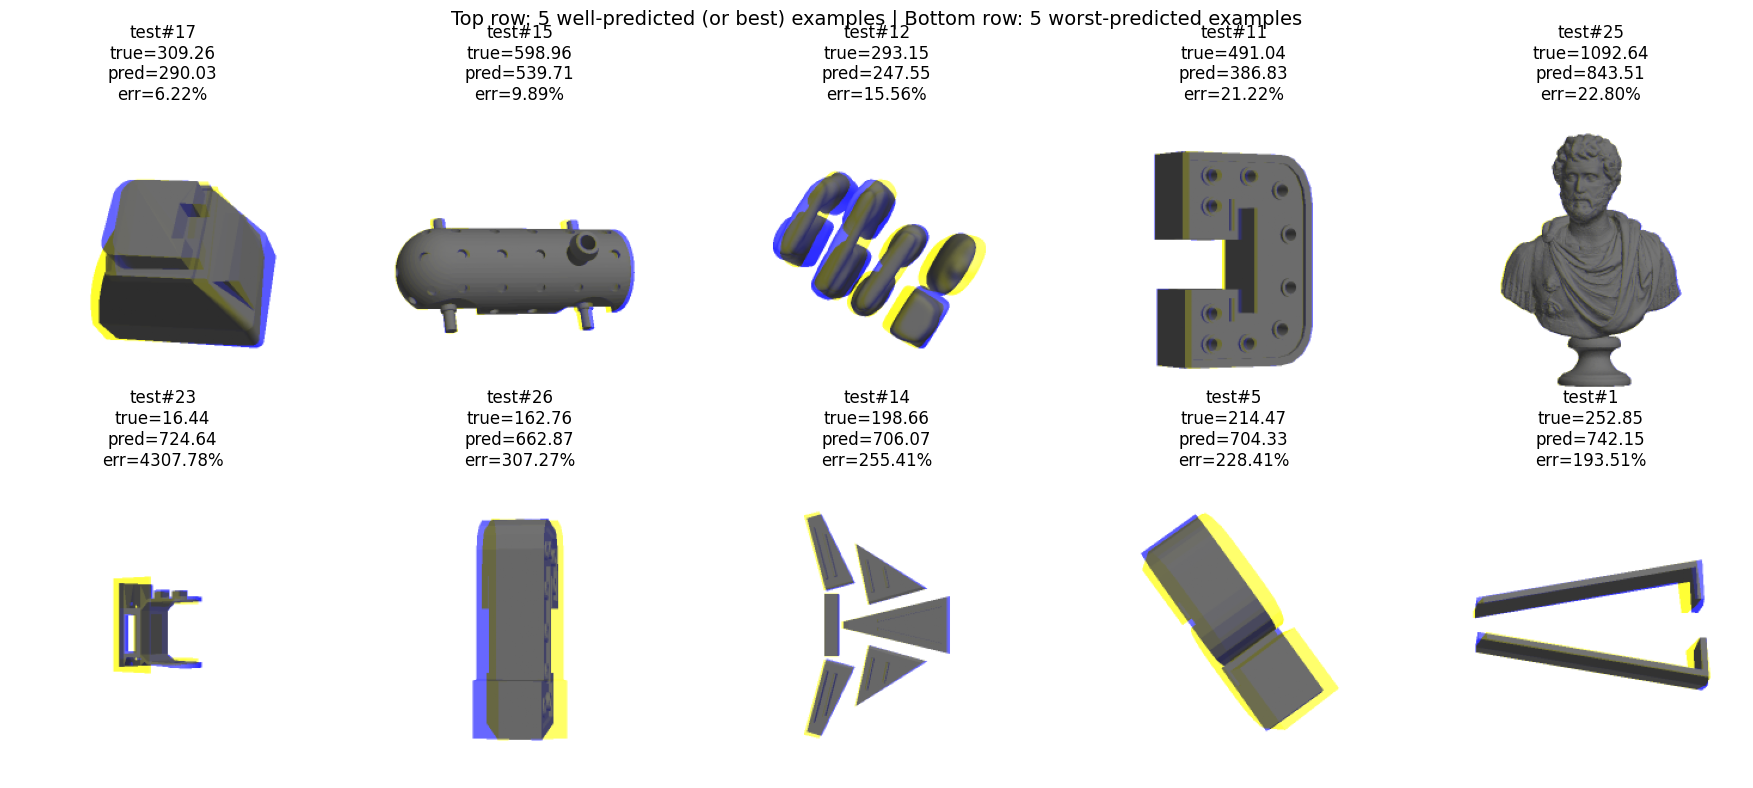

In [17]:
import numpy as np

# Select and display 5 well-predicted (<5% error) and 5 worst-predicted test examples.
import matplotlib.pyplot as plt

# ensure flattened
y_pred_arr = np.asarray(y_pred).flatten()
y_test_arr = np.asarray(y_test).flatten()

# percentage absolute error (guard against division by zero)
eps = 1e-6
pct_err = np.abs(y_pred_arr - y_test_arr) / np.maximum(np.abs(y_test_arr), eps)

# sorted indices by error
sorted_idx = np.argsort(pct_err)
# well-predicted indices (error < 5%)
well_mask = pct_err < 0.05
well_candidates = sorted_idx[well_mask[sorted_idx]]
# pick up to 5 from true <5% set, fill with best remaining if fewer
n_well = 5
well_idx = list(well_candidates[:n_well])
if len(well_idx) < n_well:
    for idx in sorted_idx:
        if idx not in well_idx:
            well_idx.append(idx)
        if len(well_idx) == n_well:
            break

# worst 5 (largest pct error)
worst_idx = list(np.argsort(pct_err)[-5:][::-1])

# display
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for col, idx in enumerate(well_idx):
    left = X_test[idx, :, :, 0]
    right = X_test[idx, :, :, 1]
    vis = np.stack([right, right, left], axis=-1)
    ax = axes[0, col]
    ax.imshow(vis)
    ax.set_title(f"test#{idx}\ntrue={y_test_arr[idx]:.2f}\npred={y_pred_arr[idx]:.2f}\nerr={pct_err[idx]*100:.2f}%")
    ax.axis("off")

for col, idx in enumerate(worst_idx):
    left = X_test[idx, :, :, 0]
    right = X_test[idx, :, :, 1]
    vis = np.stack([right, right, left], axis=-1)
    ax = axes[1, col]
    ax.imshow(vis)
    ax.set_title(f"test#{idx}\ntrue={y_test_arr[idx]:.2f}\npred={y_pred_arr[idx]:.2f}\nerr={pct_err[idx]*100:.2f}%")
    ax.axis("off")

plt.suptitle("Top row: 5 well-predicted (or best) examples | Bottom row: 5 worst-predicted examples", fontsize=14)
plt.tight_layout()
plt.show()

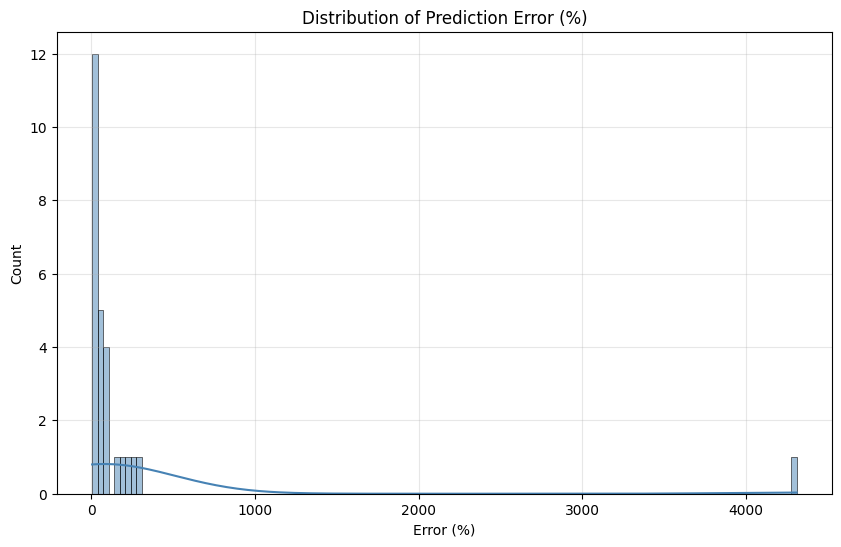

In [23]:
import seaborn as sns

import matplotlib.pyplot as plt

error_pct = pct_err * 100

plt.figure(figsize=(10, 6))
sns.histplot(error_pct, bins=128, kde=True, color="steelblue")
plt.xlabel("Error (%)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Error (%)")
plt.grid(True, alpha=0.3)
plt.show()